
Dataset Loaded Successfully!

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  price
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556  4.526
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842  3.585
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260  3.521
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945  3.413
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467  3.422

Dataset Shape: (20640, 7)

Basic Statistics:
              MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.0

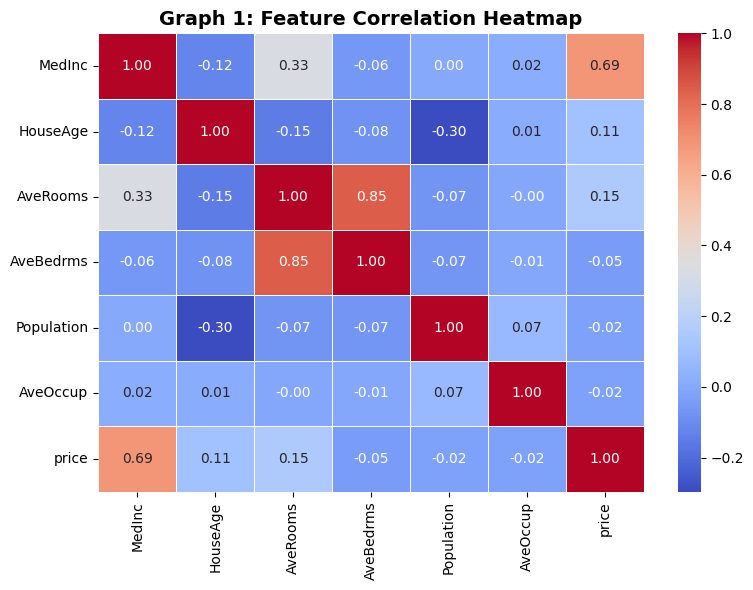

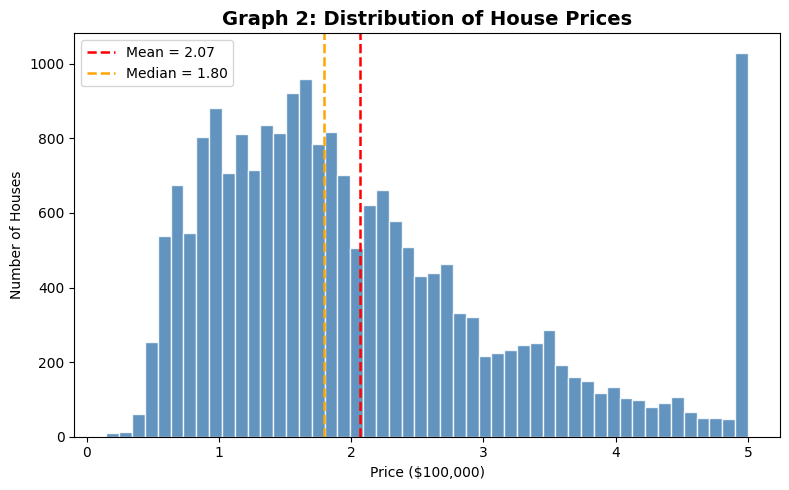


Model Trained Successfully!

Training R2 Score : 0.8626
Test     R2 Score : 0.6780
Training MAE      : 0.3157
Test     MAE      : 0.4701


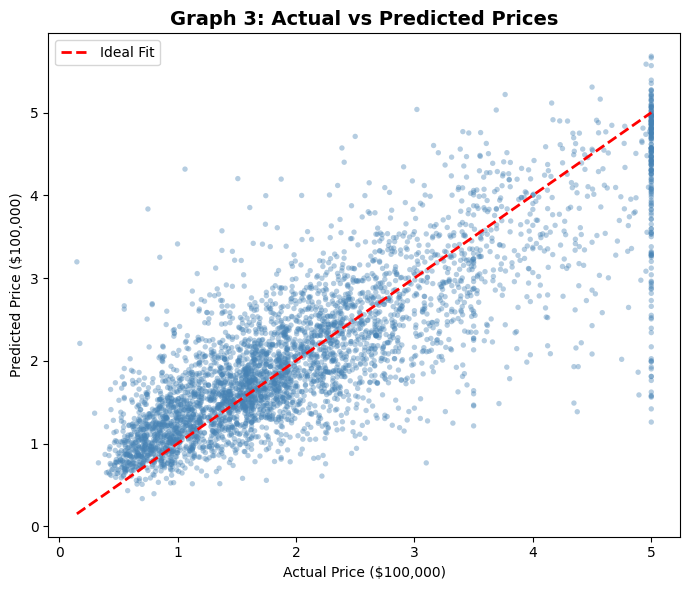

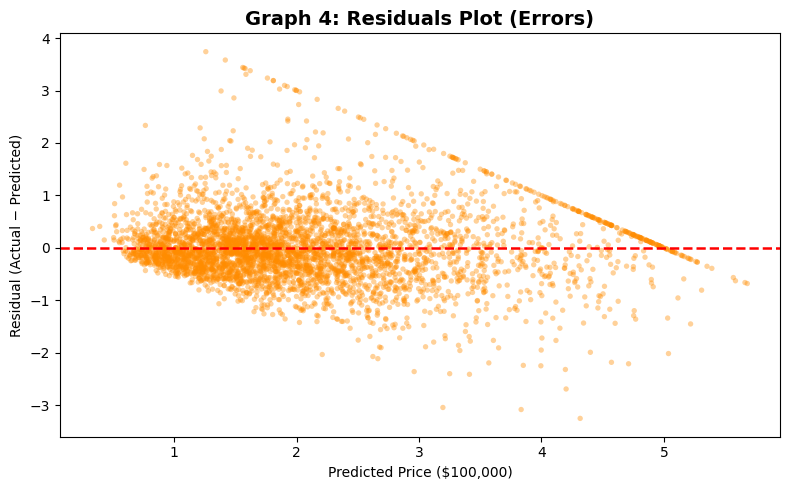

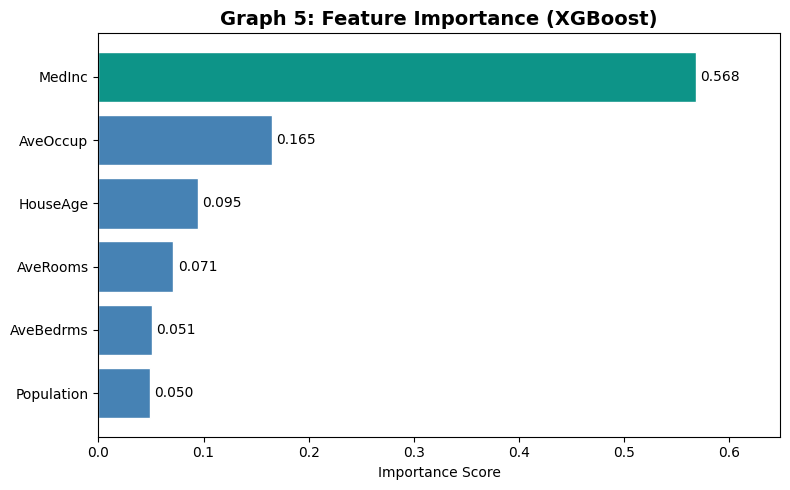

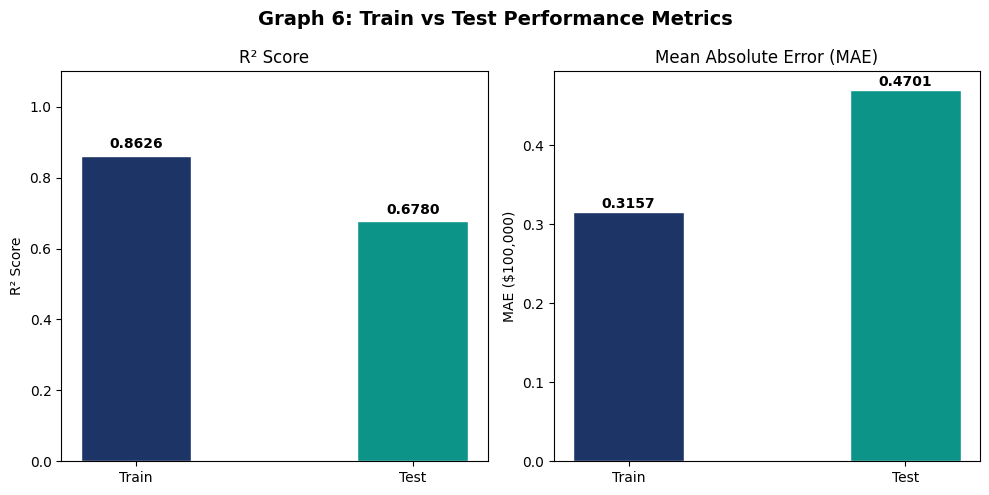


===== Enter Details for Prediction =====
Median Income    (Example: 3.5 ): 3
House Age        (Example: 25  ): 2
Average Rooms    (Example: 5   ): 1
Average Bedrooms (Example: 1   ): 1
Population       (Example: 1000): 2
Average Occupancy(Example: 3   ): 1

🏠 Predicted House Price : 2.6298
💰 Estimated Price       : $262,981


In [1]:
# House Price Prediction (Enhanced Version)
# With Multiple Graphs & Visualizations
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.datasets
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn import metrics

# ============================================
# 1. Load Dataset
# ============================================

data = sklearn.datasets.fetch_california_housing()

df = pd.DataFrame(data.data, columns=data.feature_names)

# Drop Latitude & Longitude
df = df.drop(['Latitude', 'Longitude'], axis=1)

# Add target
df['price'] = data.target

print("\nDataset Loaded Successfully!\n")
print(df.head())
print("\nDataset Shape:", df.shape)
print("\nBasic Statistics:\n", df.describe())

# ============================================
# 2. GRAPH 1 — Correlation Heatmap
# ============================================

plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title("Graph 1: Feature Correlation Heatmap", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================
# 3. GRAPH 2 — Price Distribution
# ============================================

plt.figure(figsize=(8, 5))
plt.hist(df['price'], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
plt.axvline(df['price'].mean(), color='red', linestyle='--', linewidth=1.8, label=f"Mean = {df['price'].mean():.2f}")
plt.axvline(df['price'].median(), color='orange', linestyle='--', linewidth=1.8, label=f"Median = {df['price'].median():.2f}")
plt.title("Graph 2: Distribution of House Prices", fontsize=14, fontweight='bold')
plt.xlabel("Price ($100,000)")
plt.ylabel("Number of Houses")
plt.legend()
plt.tight_layout()
plt.show()

# ============================================
# 4. Split Data
# ============================================

X = df.drop('price', axis=1)
Y = df['price']

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=2
)

# ============================================
# 5. Train Model
# ============================================

model = XGBRegressor()
model.fit(X_train, Y_train)

print("\nModel Trained Successfully!\n")

# ============================================
# 6. Evaluation
# ============================================

train_pred = model.predict(X_train)
test_pred  = model.predict(X_test)

train_r2  = metrics.r2_score(Y_train, train_pred)
test_r2   = metrics.r2_score(Y_test,  test_pred)
train_mae = metrics.mean_absolute_error(Y_train, train_pred)
test_mae  = metrics.mean_absolute_error(Y_test,  test_pred)

print(f"Training R2 Score : {train_r2:.4f}")
print(f"Test     R2 Score : {test_r2:.4f}")
print(f"Training MAE      : {train_mae:.4f}")
print(f"Test     MAE      : {test_mae:.4f}")

# ============================================
# 7. GRAPH 3 — Actual vs Predicted
# ============================================

plt.figure(figsize=(7, 6))
plt.scatter(Y_test, test_pred, alpha=0.4, color='steelblue', edgecolors='none', s=15)
plt.plot([Y_test.min(), Y_test.max()],
         [Y_test.min(), Y_test.max()],
         'r--', linewidth=2, label='Ideal Fit')
plt.title("Graph 3: Actual vs Predicted Prices", fontsize=14, fontweight='bold')
plt.xlabel("Actual Price ($100,000)")
plt.ylabel("Predicted Price ($100,000)")
plt.legend()
plt.tight_layout()
plt.show()

# ============================================
# 8. GRAPH 4 — Residuals Plot
# ============================================

residuals = Y_test.values - test_pred

plt.figure(figsize=(8, 5))
plt.scatter(test_pred, residuals, alpha=0.4, color='darkorange', edgecolors='none', s=15)
plt.axhline(y=0, color='red', linestyle='--', linewidth=1.8)
plt.title("Graph 4: Residuals Plot (Errors)", fontsize=14, fontweight='bold')
plt.xlabel("Predicted Price ($100,000)")
plt.ylabel("Residual (Actual − Predicted)")
plt.tight_layout()
plt.show()

# ============================================
# 9. GRAPH 5 — Feature Importance
# ============================================

importances = model.feature_importances_
feature_names = X.columns.tolist()

# Sort by importance
sorted_idx = np.argsort(importances)
sorted_features = [feature_names[i] for i in sorted_idx]
sorted_values   = importances[sorted_idx]

plt.figure(figsize=(8, 5))
colors = ['#0D9488' if v == sorted_values.max() else 'steelblue' for v in sorted_values]
bars = plt.barh(sorted_features, sorted_values, color=colors, edgecolor='white')
plt.bar_label(bars, fmt='%.3f', padding=3, fontsize=10)
plt.title("Graph 5: Feature Importance (XGBoost)", fontsize=14, fontweight='bold')
plt.xlabel("Importance Score")
plt.xlim(0, sorted_values.max() + 0.08)
plt.tight_layout()
plt.show()

# ============================================
# 10. GRAPH 6 — Train vs Test Metrics Bar Chart
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle("Graph 6: Train vs Test Performance Metrics", fontsize=14, fontweight='bold')

# R² comparison
axes[0].bar(['Train', 'Test'], [train_r2, test_r2],
            color=['#1C3566', '#0D9488'], width=0.4, edgecolor='white')
axes[0].set_title("R² Score", fontsize=12)
axes[0].set_ylim(0, 1.1)
axes[0].set_ylabel("R² Score")
for i, v in enumerate([train_r2, test_r2]):
    axes[0].text(i, v + 0.02, f"{v:.4f}", ha='center', fontweight='bold')

# MAE comparison
axes[1].bar(['Train', 'Test'], [train_mae, test_mae],
            color=['#1C3566', '#0D9488'], width=0.4, edgecolor='white')
axes[1].set_title("Mean Absolute Error (MAE)", fontsize=12)
axes[1].set_ylabel("MAE ($100,000)")
for i, v in enumerate([train_mae, test_mae]):
    axes[1].text(i, v + 0.005, f"{v:.4f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================
# 11. User Input
# ============================================

print("\n===== Enter Details for Prediction =====")

try:
    MedInc     = float(input("Median Income    (Example: 3.5 ): "))
    HouseAge   = float(input("House Age        (Example: 25  ): "))
    AveRooms   = float(input("Average Rooms    (Example: 5   ): "))
    AveBedrms  = float(input("Average Bedrooms (Example: 1   ): "))
    Population = float(input("Population       (Example: 1000): "))
    AveOccup   = float(input("Average Occupancy(Example: 3   ): "))

    input_data = np.array([[MedInc, HouseAge, AveRooms,
                            AveBedrms, Population, AveOccup]])

    prediction = model.predict(input_data)

    print(f"\n🏠 Predicted House Price : {prediction[0]:.4f}")
    print(f"💰 Estimated Price       : ${prediction[0] * 100000:,.0f}")

except ValueError:
    print("❌ Please enter valid numeric values!")